# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [22]:
# The dataset collected is related to 17 campaigns that occurred between May 2008 and November 2010

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.tree import plot_tree
import time

In [24]:
bank_full_df = pd.read_csv('../data/bank-additional-full.csv', sep = ';')

In [25]:
bank_full_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [26]:
bank_full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [27]:
bank_full_df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [28]:
bank_full_df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


<Axes: ylabel='age'>

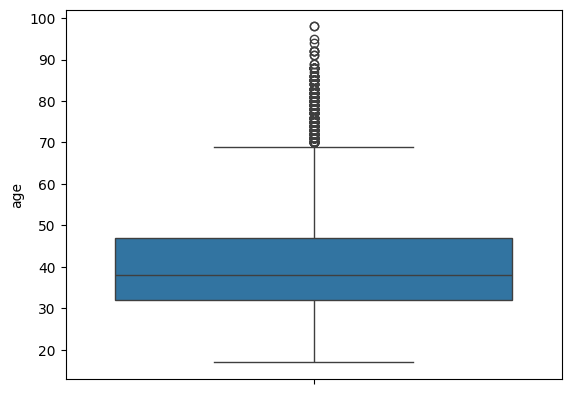

In [29]:
# Exploring age column using data visualization
sns.boxplot(bank_full_df['age'])

In [30]:
# Exploring how many of bank's clients are above age of 75
bank_full_df[bank_full_df['age'] > 75]['age'].count()

np.int64(245)

In [31]:
# Undersating distribution of data in job column
bank_full_df['job'].value_counts()

,count
job,
admin.,10422
blue-collar,9254
technician,6743
services,3969
management,2924
retired,1720
entrepreneur,1456
self-employed,1421
housemaid,1060


In [32]:
bank_full_df['campaign'].value_counts()

,count
campaign,
1,17642
2,10570
3,5341
4,2651
5,1599
6,979
7,629
8,400
9,283


In [33]:
bank_full_df['pdays'].value_counts()

,count
pdays,
999,39673
3,439
6,412
4,118
9,64
2,61
7,60
12,58
10,52


In [34]:
bank_full_df['previous'].value_counts()

,count
previous,
0,35563
1,4561
2,754
3,216
4,70
5,18
6,5
7,1


In [35]:
bank_full_df['poutcome'].value_counts()

,count
poutcome,
nonexistent,35563
failure,4252
success,1373


<Axes: ylabel='campaign'>

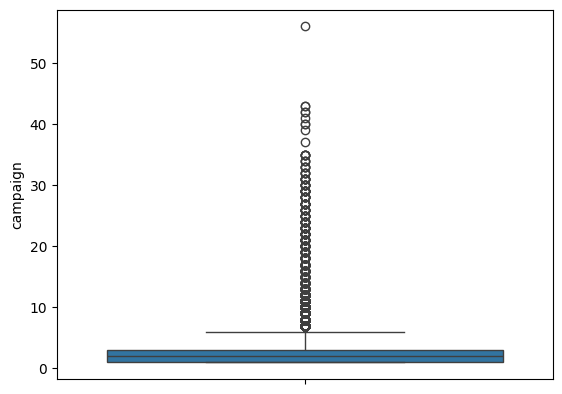

In [36]:
sns.boxplot(bank_full_df['campaign'])

In [37]:
bank_full_df[bank_full_df['campaign'] > 10]['campaign'].count()

np.int64(869)

In [38]:
# Exploring the probability distribution of the columns with data type is object
def print_data_dist(df, col):
    print("")
    print(df[col].value_counts(normalize = True))
cat_col_lst = bank_full_df.select_dtypes(include = 'object').columns
for col in cat_col_lst:
  print_data_dist(bank_full_df, col)


job
admin.           0.253035
blue-collar      0.224677
technician       0.163713
services         0.096363
management       0.070992
retired          0.041760
entrepreneur     0.035350
self-employed    0.034500
housemaid        0.025736
unemployed       0.024619
student          0.021244
unknown          0.008012
Name: proportion, dtype: float64

marital
married     0.605225
single      0.280859
divorced    0.111974
unknown     0.001942
Name: proportion, dtype: float64

education
university.degree      0.295426
high.school            0.231014
basic.9y               0.146766
professional.course    0.127294
basic.4y               0.101389
basic.6y               0.055647
unknown                0.042027
illiterate             0.000437
Name: proportion, dtype: float64

default
no         0.791201
unknown    0.208726
yes        0.000073
Name: proportion, dtype: float64

housing
yes        0.523842
no         0.452122
unknown    0.024036
Name: proportion, dtype: float64

loan
no         0.8

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

**Business Objective**

The business objective is to identify best machine learning classification model which can predict the customer buying the term deposit with the aim to find as many buyers possible who can be potential customers while utilizing the marketing resources most effectively so to minimize spending them on people not likely to buy.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [39]:
bank_full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [40]:
# drop columns not included

bank_full_df.drop(columns = ['duration', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'], inplace = True)


In [41]:
bank_full_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,no


In [42]:
# Replace the unknown value in [job, marital, default, loan] columns with the value which has the highest occurances
bank_full_df['job'] = bank_full_df['job'].replace('unknown', 'admin.')
bank_full_df['marital'] = bank_full_df['marital'].replace('unknown', 'married')
bank_full_df['default'] = bank_full_df['default'].replace('unknown', 'no')
bank_full_df['loan'] = bank_full_df['loan'].replace('unknown', 'no')



In [43]:
# Added a generic method to calculate the probablity of the column passed as an input  and dataframe and fill the missing values in the column using the probability disctribution calculated
def populate_missing_data_using_prob_dist(df, col_name):
  # Calculate probabilities of existing column values
  probs_col = df[col_name].value_counts(normalize=True)
  # Identify missing values
  missing_mask = df[col_name].isnull()
  # Sample from existing values using the calculated probabilities
  fill_values = np.random.choice(
      a=probs_col.index,
      size=missing_mask.sum(),
      p=probs_col.values
  )
  # Apply the sampled values
  df.loc[missing_mask, col_name] = fill_values

In [44]:
# Populate the unknown values in [education, housing] columns as per the probablity distribution of the column
bank_full_df['education'] = bank_full_df['education'].replace('unknown', np.nan)
bank_full_df['housing'] = bank_full_df['housing'].replace('unknown', np.nan)
populate_missing_data_using_prob_dist(bank_full_df, 'education')
populate_missing_data_using_prob_dist(bank_full_df, 'housing')


In [45]:
# Droping the rows where the campaign value is greater than 10
bank_full_df = bank_full_df[bank_full_df['campaign'] <= 10]

In [46]:
bank_full_df['campaign'].value_counts()

,count
campaign,
1,17642
2,10570
3,5341
4,2651
5,1599
6,979
7,629
8,400
9,283


In [47]:
# Create a new column previously_contacted with binary values based on pdays where value of 999 means not contacted otherwise contacted
bank_full_df['previously_contacted'] = bank_full_df['pdays'].apply(lambda x: 1 if x != 999 else 0)
bank_full_df.drop(columns = ['pdays'], inplace = True)
bank_full_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,y,previously_contacted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,0,nonexistent,no,0
1,57,services,married,high.school,no,no,no,telephone,may,mon,1,0,nonexistent,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,0,nonexistent,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,0,nonexistent,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,0,nonexistent,no,0


In [48]:
# Create a column contacted with binary values based on the value in previous column
bank_full_df['contacted'] = bank_full_df['previous'].apply(lambda x: 1 if x > 0 else 0)
bank_full_df.drop(columns = ['previous'], inplace = True)
bank_full_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,poutcome,y,previously_contacted,contacted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,nonexistent,no,0,0
1,57,services,married,high.school,no,no,no,telephone,may,mon,1,nonexistent,no,0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,nonexistent,no,0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,nonexistent,no,0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,nonexistent,no,0,0


In [49]:
bank_full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40319 entries, 0 to 41187
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   age                   40319 non-null  int64 
 1   job                   40319 non-null  object
 2   marital               40319 non-null  object
 3   education             40319 non-null  object
 4   default               40319 non-null  object
 5   housing               40319 non-null  object
 6   loan                  40319 non-null  object
 7   contact               40319 non-null  object
 8   month                 40319 non-null  object
 9   day_of_week           40319 non-null  object
 10  campaign              40319 non-null  int64 
 11  poutcome              40319 non-null  object
 12  y                     40319 non-null  object
 13  previously_contacted  40319 non-null  int64 
 14  contacted             40319 non-null  int64 
dtypes: int64(4), object(11)
memory usage: 4.9

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [50]:
X = bank_full_df.drop(columns = ['y'])
y = bank_full_df['y']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size=0.3)

In [52]:
y_test.value_counts()

,count
y,
no,10665
yes,1431


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

**Baseline Performance**

Since we saw that the target class data is highly imbalanced in the dataset with 89% 'No' and 11% 'Yes', the baseline accuracy is 89% since the dummy model which does not even look at data and picks 'No' for every person will be correct almost 89% of time. However it will have the recall of 0% and will not be able to find a single potential customer.
So the score for Accuracy may not be the only stats that we need to look at, we also need to check Recall which gives us how many potential customers we were able to find out of total number of potential customers and Precision which gives us how many out of total we predicted will buy the term deposit actually end up buying the product. So ideally our Baseline performance will be to keep the Accuracy level high which having a good balance of Precision and Recall.  

In [53]:
le = LabelEncoder()
y = le.fit_transform(y)

categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
categorical_columns.remove('education')
numerical_columns = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
edu_order = [
    'illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
    'high.school', 'professional.course', 'university.degree'
]
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(drop='first'), categorical_columns),
        ('edu', OrdinalEncoder(categories=[edu_order]), ['education'])
    ]
)

poly_preprocessor = ColumnTransformer(
    transformers=[
        # 1. Numerical branch (Standardized + Polynomials)
        ('num_pipe', Pipeline([
            ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ('scaler', StandardScaler())
        ]), numerical_columns),

        # 2. Categorical branch (OneHot first, THEN Polynomials)
        ('cat_pipe', Pipeline([
            ('ohe', OneHotEncoder(drop='first', sparse_output=False)),
            ('poly', PolynomialFeatures(interaction_only=True, include_bias=False))
        ]), categorical_columns),

        # 3. Education branch (Ordinal first, THEN Polynomials)
        ('edu_pipe', Pipeline([
            ('ord', OrdinalEncoder(categories=[edu_order])),
            ('poly', PolynomialFeatures(degree=2, include_bias=False))
        ]), ['education'])
    ]
)

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

### Problem 9: Score the Model

What is the accuracy of your model?

In [54]:
# Building the basic Logistic Regression model with setting class_weight=balanced since we have a very
# imbalanced target classes with No as 89% and Yes as 11%. Without setting this parameter, this model will be
# completely useless since it will pick always from No class
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced'))
])
start_time = time.time()
lr_pipe.fit(X_train, y_train)
end_time = time.time()
training_time = end_time - start_time
# Find the accuracy of the model on train and test data sets
y_pred_train = lr_pipe.predict(X_train)
y_pred_test = lr_pipe.predict(X_test)
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
lr_results = []
lr_results.append(['LogisticRegression', training_time, train_accuracy, test_accuracy])

lr_results_df = pd.DataFrame(lr_results, columns=['Model', 'Training Time', 'Train Accuracy', 'Test Accuracy'])
print(lr_results_df)
print()
print("Classification Results for further inquiry")
print(classification_report(y_test, y_pred_test))

                Model  Training Time  Train Accuracy  Test Accuracy
0  LogisticRegression       1.097301        0.817489        0.81746

Classification Results for further inquiry
              precision    recall  f1-score   support

          no       0.93      0.86      0.89     10665
         yes       0.33      0.54      0.41      1431

    accuracy                           0.82     12096
   macro avg       0.63      0.70      0.65     12096
weighted avg       0.86      0.82      0.83     12096



In [55]:
# Exploring the LogisticRegression using the Polynomical features to check if it improves the Precision and Recall in Classification report
lr_pipe = Pipeline([
    ('preprocessor', poly_preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced'))
])
start_time = time.time()
lr_pipe.fit(X_train, y_train)
end_time = time.time()
training_time = end_time - start_time
# Find the accuracy of the model on train and test data sets
y_pred_train = lr_pipe.predict(X_train)
y_pred_test = lr_pipe.predict(X_test)
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
lr_results = []
lr_results.append(['LogisticRegression', training_time, train_accuracy, test_accuracy])

lr_results_df = pd.DataFrame(lr_results, columns=['Model', 'Training Time', 'Train Accuracy', 'Test Accuracy'])
print(lr_results_df)
print()
print("Classification Results for further inquiry")
print(classification_report(y_test, y_pred_test))

                Model  Training Time  Train Accuracy  Test Accuracy
0  LogisticRegression       4.441328        0.811076       0.798611

Classification Results for further inquiry
              precision    recall  f1-score   support

          no       0.93      0.83      0.88     10665
         yes       0.31      0.57      0.40      1431

    accuracy                           0.80     12096
   macro avg       0.62      0.70      0.64     12096
weighted avg       0.86      0.80      0.82     12096



**Since the Logistic Regression with polynomial features does not provide any substantial improvement over basic Logistic Regression but has higher training time, we will not be considering polynomial features going forward in this exercise**.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [56]:
# Since the dataset is highly imbalanced for the target class, we are going to use class_weight='balanced' for LR, DT and SVM and weight='distance'
# for KNN
models = {
    'logistic_regression': LogisticRegression(class_weight='balanced'),
    'knn': KNeighborsClassifier(weights='distance'),
    'decision_ tree': DecisionTreeClassifier(class_weight='balanced'),
    'svm': SVC(class_weight='balanced')
}
model_results = []
for model_name, model in models.items():
    model_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    start_time = time.time()
    model_pipe.fit(X_train, y_train)
    end_time = time.time()
    training_time = end_time - start_time
    y_pred_train = model_pipe.predict(X_train)
    y_pred_test = model_pipe.predict(X_test)
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test,pos_label='yes')
    recall = recall_score(y_test, y_pred_test, pos_label='yes')
    model_results.append([model_name, training_time, train_accuracy, test_accuracy, precision, recall])
# model_results
model_results_df = pd.DataFrame(model_results, columns=['Model', 'Training Time', 'Train Accuracy', 'Test Accuracy', 'Precision', 'Recall'])
model_results_df

,Model,Training Time,Train Accuracy,Test Accuracy,Precision,Recall
0,logistic_regression,0.518956,0.817489,0.817460,0.331891,0.535989
1,knn,0.142809,0.993055,0.878142,0.469242,0.229210
2,decision_ tree,1.160889,0.991496,0.825976,0.274431,0.286513
3,svm,96.720316,0.838536,0.836062,0.365497,0.524109


**From the results of the models with the default settings, LogisticRegression and SVM looks promising provising almost same Accuracy and good balance of Precision and Recall. However SVM is very slow to train compared to LogisticRegression while delivering almost comparable performance.**

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [58]:
# Optimizing the Logistic Regression Classifier to improve the quality of results

models = {
    'logistic_regression': (LogisticRegression(class_weight='balanced'), {'classifier__C': [0.01, 0.1, 1, 10, 100]}),
    'ridge': (RidgeClassifier(class_weight='balanced'), {'classifier__alpha': [0.01, 0.1, 1, 10, 100]})
}
model_results = []
for model_name, (model, param_grid) in models.items():
    model_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    grid_search = GridSearchCV(model_pipe, param_grid, cv=5, scoring='recall')
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid_search.cv_results_['mean_fit_time'])
    # training_time = end_time - start_time
    print(grid_search.best_params_)
    y_pred_train = grid_search.predict(X_train)
    y_pred_test = grid_search.predict(X_test)
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test,pos_label='yes')
    recall = recall_score(y_test, y_pred_test, pos_label='yes')
    model_results.append([model_name, fit_time, train_accuracy, test_accuracy, precision, recall])

model_results_df = pd.DataFrame(model_results, columns=['Model', 'Training Time', 'Train Accuracy', 'Test Accuracy', 'Precision', 'Recall'])
model_results_df


{'classifier__C': 0.01}
{'classifier__alpha': 0.01}


,Model,Training Time,Train Accuracy,Test Accuracy,Precision,Recall
0,logistic_regression,2.211044,0.800553,0.802993,0.313772,0.560447
1,ridge,1.591738,0.814867,0.814980,0.328225,0.538784


In [59]:
# In the previous logistic regression run, GridSearchCV picked the lowed value provided for the regularization for C and aplha, trying even lower
# value to see if that improves the performance of the model

models = {
    'logistic_regression': (LogisticRegression(class_weight='balanced'), {'classifier__C': [0.001, 0.01]}),
    'ridge': (RidgeClassifier(class_weight='balanced'), {'classifier__alpha': [0.001, 0.01]}),
}
model_results = []
for model_name, (model, param_grid) in models.items():
    model_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    grid_search = GridSearchCV(model_pipe, param_grid, cv=5, scoring='recall')
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid_search.cv_results_['mean_fit_time'])
    print(grid_search.best_params_)
    y_pred_train = grid_search.predict(X_train)
    y_pred_test = grid_search.predict(X_test)
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test,pos_label='yes')
    recall = recall_score(y_test, y_pred_test, pos_label='yes')
    model_results.append([model_name, fit_time, train_accuracy, test_accuracy, precision, recall])

model_results_df = pd.DataFrame(model_results, columns=['Model', 'Training Time', 'Train Accuracy', 'Test Accuracy', 'Precision', 'Recall'])
model_results_df

{'classifier__C': 0.001}
{'classifier__alpha': 0.001}


,Model,Training Time,Train Accuracy,Test Accuracy,Precision,Recall
0,logistic_regression,2.216793,0.766609,0.764468,0.268754,0.575821
1,ridge,1.428180,0.814867,0.814980,0.328225,0.538784


**The GridSearchCV choose the lowest value for C and alpha that was provided since the scoring is set to recall, it is trying to find the maximum potential customers. However the precision for LR dropped from 31% to 26% while the Ridge status remain mostly same. So it looks like the LR model had find the good balance between precision and recall with previous value of hyperparameter C as 0.01. Also since the LR is performing better than Ridge, we will only consider LogisticRegression going forward from LR family of classifiers.**

In [60]:
# Optimizing the KNN to improve the quality of results

models = {
    'knn': (KNeighborsClassifier(weights='distance'), {'knn__n_neighbors': [3, 5, 7]}),
}
model_results = []
for model_name, (model, param_grid) in models.items():
    model_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('knn', model)
    ])
    grid_search = GridSearchCV(model_pipe, param_grid, cv=5, scoring='recall')
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid_search.cv_results_['mean_fit_time'])
    print(grid_search.best_params_)
    y_pred_train = grid_search.predict(X_train)
    y_pred_test = grid_search.predict(X_test)
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test,pos_label='yes')
    recall = recall_score(y_test, y_pred_test, pos_label='yes')
    model_results.append([model_name, fit_time, train_accuracy, test_accuracy, precision, recall])

model_results_df = pd.DataFrame(model_results, columns=['Model', 'Training Time', 'Train Accuracy', 'Test Accuracy', 'Precision', 'Recall'])
model_results_df

{'knn__n_neighbors': 3}


,Model,Training Time,Train Accuracy,Test Accuracy,Precision,Recall
0,knn,1.360738,0.993055,0.869461,0.411058,0.238994


{'decisiontreeclassifier__max_depth': 5}


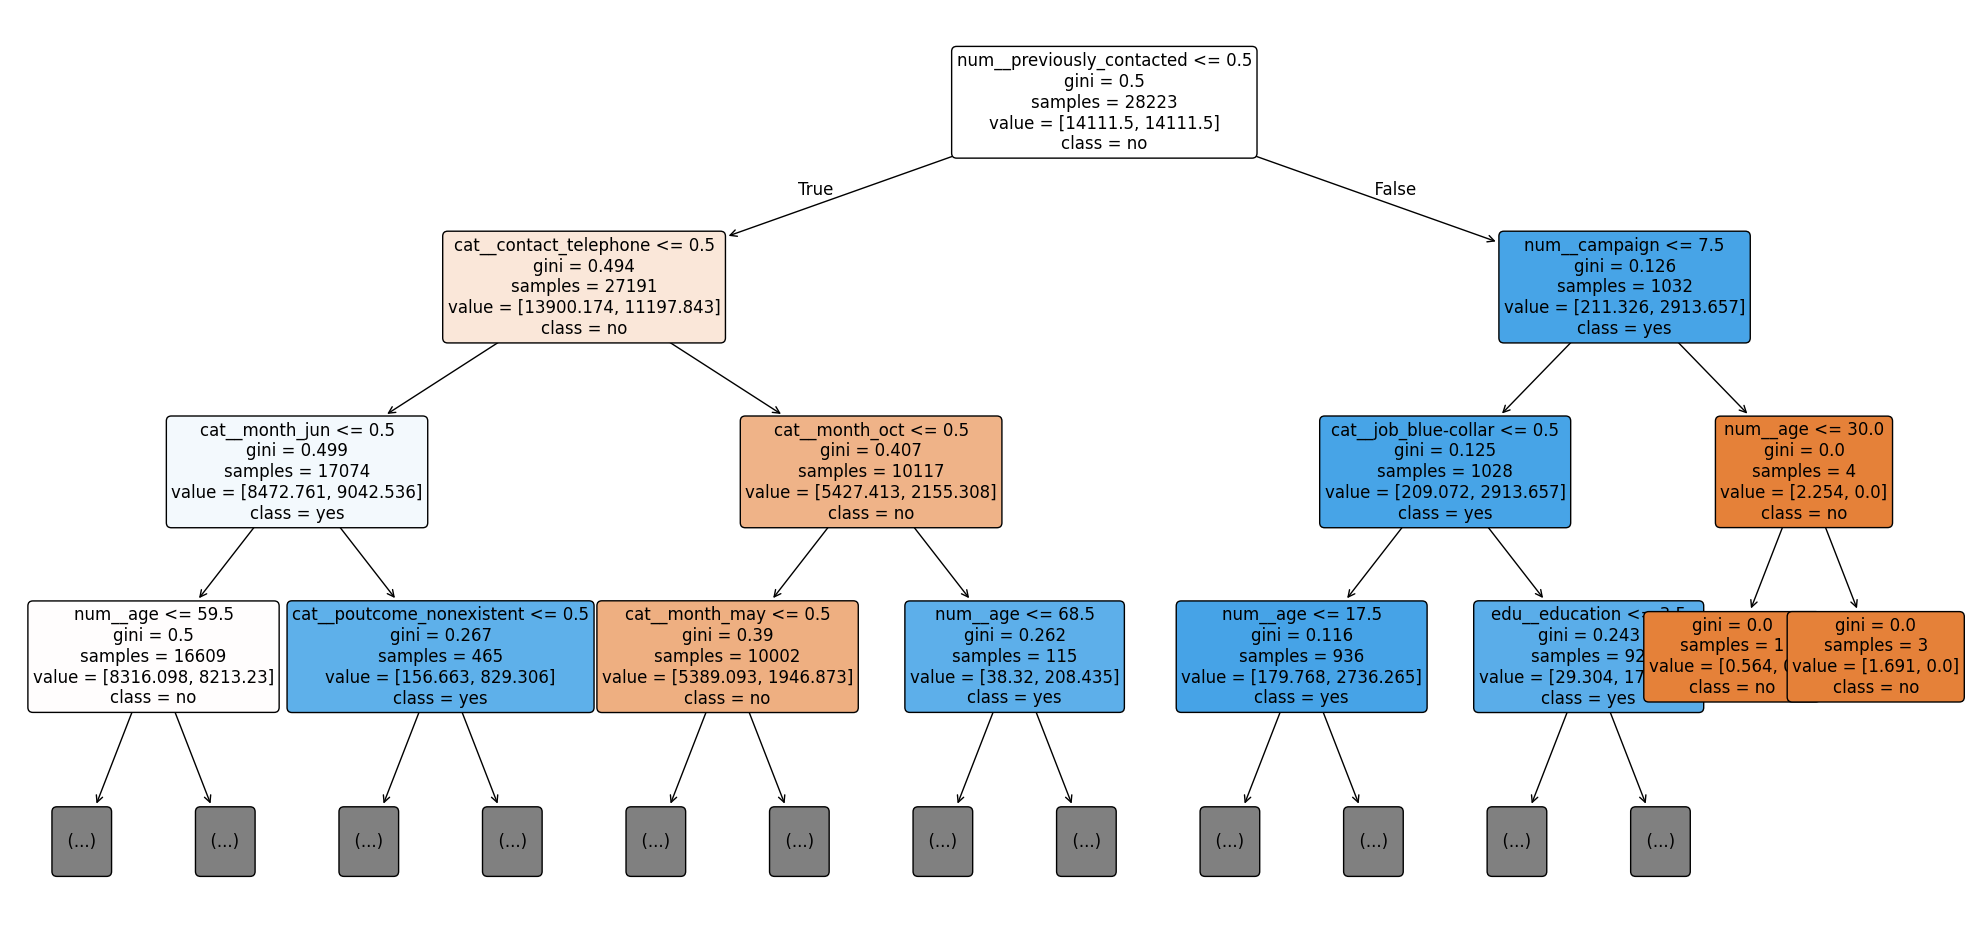

,Model,Training Time,Train Accuracy,Test Accuracy,Precision,Recall
0,decisiontreeclassifier,1.571144,0.88768,0.881944,0.501493,0.352201


In [62]:
# Optimizing the Decision Tree Classifier to improve the quality of results

dt_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_columns),
        ('edu', OrdinalEncoder(categories=[edu_order]), ['education']),
        ('num', 'passthrough', numerical_columns)
    ]
)
models = {
    'decisiontreeclassifier': (DecisionTreeClassifier(class_weight='balanced'), {'decisiontreeclassifier__max_depth': [5, 10, 15]}),
}
model_results = []
for model_name, (model, param_grid) in models.items():
    model_pipe = Pipeline([
        ('dt_preprocessor', dt_preprocessor),
        ('decisiontreeclassifier', model)
    ])
    grid_search = GridSearchCV(model_pipe, param_grid, cv=5, scoring='recall')
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid_search.cv_results_['mean_fit_time'])
    print(grid_search.best_params_)
    y_pred_train = grid_search.predict(X_train)
    y_pred_test = grid_search.predict(X_test)
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test,pos_label='yes')
    recall = recall_score(y_test, y_pred_test, pos_label='yes')
    model_results.append([model_name, fit_time, train_accuracy, test_accuracy, precision, recall])
    best_tree = grid_search.best_estimator_.named_steps['decisiontreeclassifier']

    # Get feature names after preprocessing
    transformed_feature_names = grid_search.best_estimator_.named_steps['dt_preprocessor'].get_feature_names_out()

    plt.figure(figsize=(25, 12))
    plot_tree(best_tree,
          feature_names=transformed_feature_names,  # Use the transformed feature names
          class_names=['no', 'yes'],       # Your target classes
          filled=True,                     # Colors nodes by majority
          rounded=True,
          fontsize=12,
          max_depth=3)
    plt.show()

model_results_df = pd.DataFrame(model_results, columns=['Model', 'Training Time', 'Train Accuracy', 'Test Accuracy', 'Precision', 'Recall'])
model_results_df

In [63]:
# Optimizing the SVC to improve the quality of results

models = {
    'svm': (SVC(class_weight='balanced'), {'svc__C': [0.01, 1.0], 'svc__kernel': ['rbf']}),

}
model_results = []
for model_name, (model, param_grid) in models.items():
    model_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('svc', model)
    ])
    grid_search = GridSearchCV(model_pipe, param_grid, cv=5, scoring='accuracy')
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    end_time = time.time()
    training_time = (end_time - start_time) / len(grid_search.cv_results_['mean_fit_time'])
    print(grid_search.best_params_)
    y_pred_train = grid_search.predict(X_train)
    y_pred_test = grid_search.predict(X_test)
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test,pos_label='yes')
    recall = recall_score(y_test, y_pred_test, pos_label='yes')
    model_results.append([model_name, training_time, train_accuracy, test_accuracy, precision, recall])

model_results_df = pd.DataFrame(model_results, columns=['Model', 'Training Time', 'Train Accuracy', 'Test Accuracy', 'Precision', 'Recall'])
model_results_df

{'svc__C': 0.01, 'svc__kernel': 'rbf'}


,Model,Training Time,Train Accuracy,Test Accuracy,Precision,Recall
0,svm,379.877395,0.831875,0.825479,0.320106,0.422781


{'logisticregression__C': 0.01}


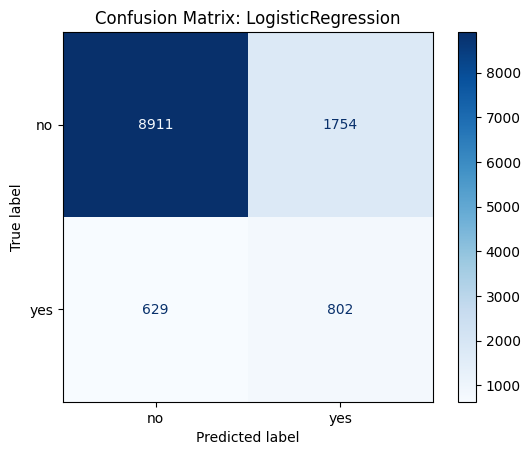

{'knn__n_neighbors': 3}


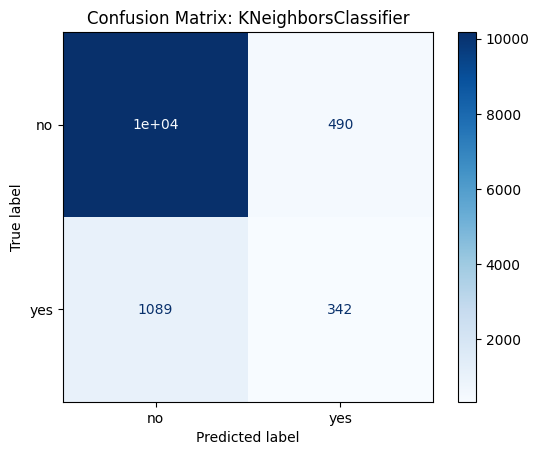

{'decisiontreeclassifier__max_depth': 5}


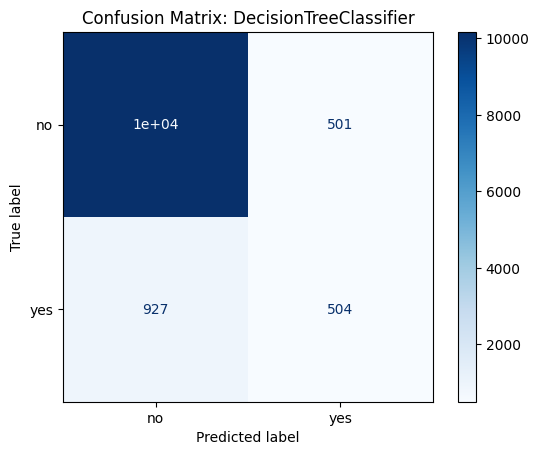

{'linearsvc__C': 0.01}


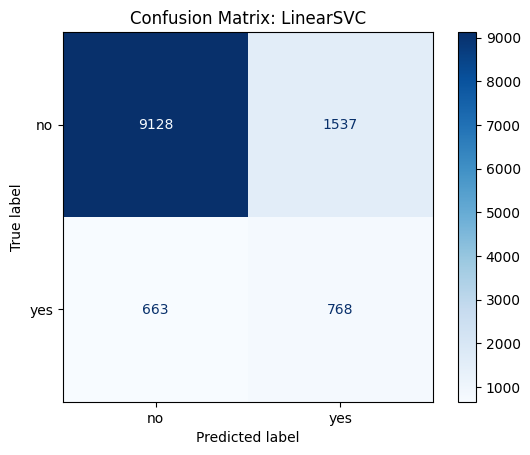

{'svc__C': 0.1, 'svc__kernel': 'rbf'}


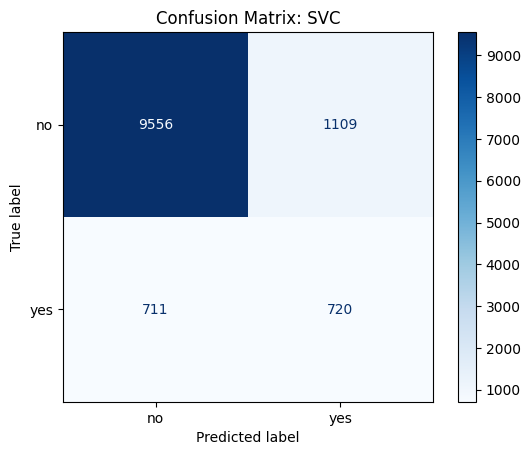

,Model,Training Time,Train Accuracy,Test Accuracy,Precision,Recall,f1 Score
0,logisticregression,2.398911,0.800553,0.802993,0.313772,0.560447,0.402307
1,knn,28.035978,0.993055,0.869461,0.411058,0.238994,0.302254
2,decisiontreeclassifier,1.640695,0.887680,0.881944,0.501493,0.352201,0.413793
3,linearsvc,1.662991,0.818340,0.818122,0.333189,0.536688,0.411135
4,svc,332.806026,0.851256,0.849537,0.393658,0.503145,0.441718


In [64]:
# combining all the models in a single pipeline with hyperparameter tuning for comparison
# Using accuracy as a scoring in GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score

le = LabelEncoder()
y = le.fit_transform(y)

categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
categorical_columns.remove('education')
numerical_columns = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
edu_order = [
    'illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
    'high.school', 'professional.course', 'university.degree'
]
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(drop='first'), categorical_columns),
        ('edu', OrdinalEncoder(categories=[edu_order]), ['education'])
    ]
)
dt_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_columns),
        ('edu', OrdinalEncoder(categories=[edu_order]), ['education']),
        ('num', 'passthrough', numerical_columns)
    ]
)

models = {
    'logisticregression': (LogisticRegression(class_weight='balanced'), {'logisticregression__C': [0.01, 0.1]}),
    'knn': (KNeighborsClassifier(weights='distance'), {'knn__n_neighbors': [3, 5, 7]}),
    'decisiontreeclassifier': (DecisionTreeClassifier(class_weight='balanced'), {'decisiontreeclassifier__max_depth': [5, 10, 15]}),
    'linearsvc': (LinearSVC(class_weight='balanced', dual=False), {'linearsvc__C': [0.01, 0.1, 1]}),
    'svc': (SVC(class_weight='balanced'), {'svc__C': [0.1, 1], 'svc__kernel': ['rbf']}),
}

model_results = []

for model_name, (model, param_grid) in models.items():
    model_pipe = None
    if model_name == 'decisiontreeclassifier':
      model_pipe = Pipeline([
          ('dt_preprocessor', dt_preprocessor),
          (model_name, model)
      ])
    else:
      model_pipe = Pipeline([
          ('preprocessor', preprocessor),
          (model_name, model)
      ])
    grid_search = GridSearchCV(model_pipe, param_grid, cv=5, scoring='accuracy')
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid_search.cv_results_['mean_fit_time'])
    print(grid_search.best_params_)
    best_model = grid_search.best_estimator_

    train_score = best_model.score(X_train, y_train)
    test_score = best_model.score(X_test, y_test)
    y_pred_test = best_model.predict(X_test)
    # Exploring the confusion matrix for the best selected by GridSearchCV based on hyperparameters
    disp = ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test,
    display_labels=['no', 'yes'],
    cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix: {type(best_model.named_steps[model_name]).__name__}")
    plt.show()

    precision = precision_score(y_test, y_pred_test,pos_label='yes')
    recall = recall_score(y_test, y_pred_test, pos_label='yes')
    f1 = f1_score(y_test, y_pred_test, pos_label='yes')
    model_results.append([model_name, fit_time, train_score, test_score, precision, recall, f1])
model_results_df = pd.DataFrame(model_results, columns=['Model', 'Training Time', 'Train Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'f1 Score'])
model_results_df

**Model Comparison Report for Bank Marketing Campaign**

Our Objective was to identify best machine learning classification model which can predict the customer buying the term deposit with the aim to find as many buyers possible who can be potential customers while utilizing the marketing resources most effectively to minimize spending them on people not likely to buy.

We ran multiple classification models to compare the Accuracy, Precision, Recall and Training time to generate the above comparison table. Since the target classes are very unbalanced in the given dataset given yes 14% to no 86%, the accuracy may not the very reliable metric for decision making. We need to look at Precision and Recall which provides a better insight in the performance of the model. Looking at the table which shows the results from the different classification models here are the key findings and model performance comparison in details.

**Key Findings**

*   If the marketing strategy is to target the buyers with the most likelihood of making purchase, than DecisionTreeClassifer model is most suitable since it has the highest Precision rate of 50% which means out of every 2 calls, one call gets converted in success. However the Recall is 35% which means it is only able to find only 35% of the potential buyers. So this model is suitable for the scenario where the marketing strategy is to quickly target the most likely customers by allocating the minimum resources or with small merketing team.
*   If the marketing strategy is to target the broader market and find as many potential customers as possible, then LogisticRegression provides a more balance between Recall and Precision. With Recall of 56%, it is able to find 56% of potential buyers much higher than 35% as discovered by DecisionTreeClassifier model. This provides a much bigger pool of potential customers for marketing team. However the Precision is 31% which means that only one in three calls will convert in success. So this model is more suitable for broader search for potential customers when more budget and bigger marketing team is available.
*  The given dataset is not a good fit for KNN model. The Training accuracy of 99% indicates overfitting and does not perform well with the test data. Though it has a decent precision of 40% but the recall is very low at 23%. Also the model is slow and has a much higher training time compared to other models except SVC-rbf.
*  LinearSVC can be a good alternative to Logistic Regression given almost comparable performance of both the models.
*  SVC-rbf provides a good balance of Precision 40% and Recall 50%, however it is extremely slow compared to the other models and show it is computationaly very expensive to operate without providing any major benefit over other models.




##### Questions